# Proyecto Compañía de Viajes Zuber
## Descripción del proyecto
Estoy trabajando como analista para Zuber, una nueva empresa de viajes compartidos que se está lanzando en Chicago. Mi tarea es encontrar patrones en la información disponible. Pretendo comprender las preferencias de los pasajeros y el impacto de los factores externos en los viajes.
Al trabajar con una base de datos, se analizará los datos de los competidores y probará una hipótesis sobre el impacto del clima en la frecuencia de los viajes.

## Descripción de los datos
Una base de datos con información sobre viajes en taxi en Chicago:

Tabla __neighborhoods__: datos sobre los barrios de la ciudad
* _name_: nombre del barrio
* _neighborhood_id_: código del barrio

Tabla __cabs__: datos sobre los taxis
* _cab_id_: código del vehículo
* _vehicle_id_: ID técnico del vehículo
* _company_name_: la empresa propietaria del vehículo

Tabla __trips__: datos sobre los viajes
* _trip_id_: código del viaje
* _cab_id_: código del vehículo que opera el viaje
* _start_ts_: fecha y hora del inicio del viaje (tiempo redondeado a la hora)
* _end_ts_: fecha y hora de finalización del viaje (tiempo redondeado a la hora)
* _duration_seconds_: duración del viaje en segundos
* _distance_miles_: distancia del viaje en millas
* _pickup_location_id_: código del barrio de recogida
* _dropoff_location_id_: código del barrio de finalización

Tabla __weather_records__: datos sobre el clima
* _record_id_: código del registro meteorológico
* _ts_: fecha y hora del registro (tiempo redondeado a la hora)
* _temperature_: temperatura cuando se tomó el registro
* _description_: breve descripción de las condiciones meteorológicas, por ejemplo, "lluvia ligera" o "nubes dispersas"

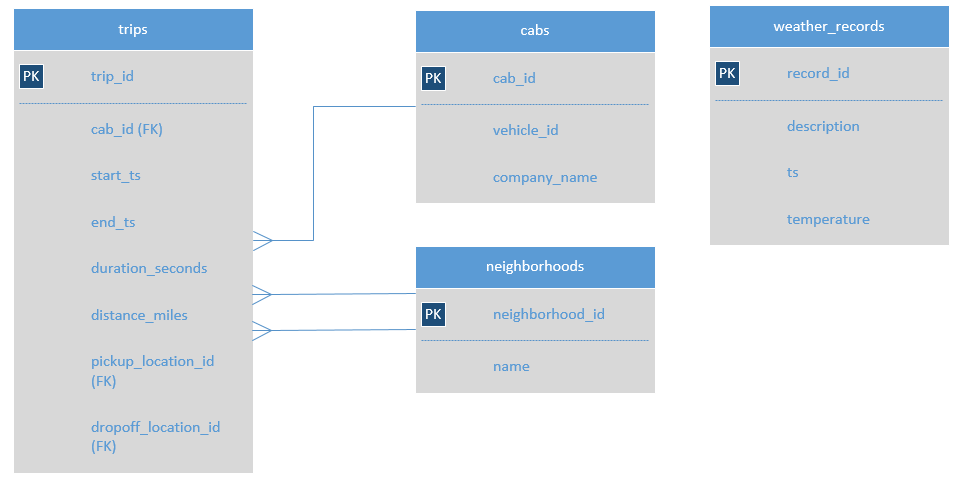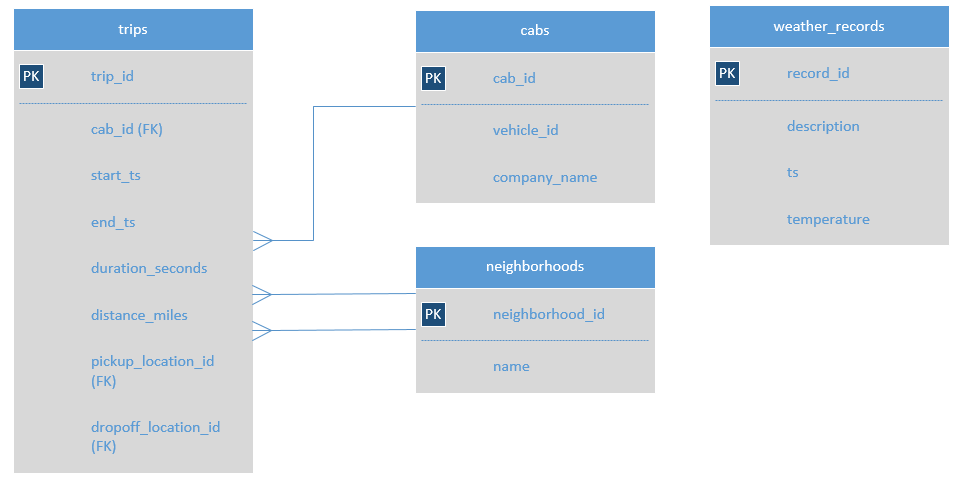

Se debe escribir un código para analizar los datos sobre el clima en _Chicago_ en noviembre de 2017 desde el sitio web:

__[https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html)__

El nombre del DataFrame debe ser `weather_records` y tienes que especificarlo cuando buscas: `attrs={"id": "weather_records"}` . Posteriormente, debo imprimir el DataFrame completo, para verificar que la información extraída sea la correcta.

#### Notas
`pandas` es una biblioteca de Python utilizada para manipular y analizar datos estructurados. Facilita tareas como cargar, limpiar y transformar datos en tablas, de forma similar a una hoja de cálculo, por lo que es ampliamente usada en análisis de datos y aprendizaje automático.

`requests` es una biblioteca de Python que permite enviar solicitudes a páginas web o APIs de forma sencilla. Con ella puedes obtener información de internet, enviar datos y trabajar con respuestas como JSON o HTML.

In [1]:
import pandas as pd
import requests

# URL del sitio
url = "https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html"

# Leer la tabla específica por id
weather_records = pd.read_html(url, attrs={"id": "weather_records"})[0]

# Imprimir el DataFrame completo
print(weather_records)

           Date and time  Temperature       Description
0    2017-11-01 00:00:00       276.15     broken clouds
1    2017-11-01 01:00:00       275.70  scattered clouds
2    2017-11-01 02:00:00       275.61   overcast clouds
3    2017-11-01 03:00:00       275.35     broken clouds
4    2017-11-01 04:00:00       275.24     broken clouds
..                   ...          ...               ...
692  2017-11-29 20:00:00       281.34        few clouds
693  2017-11-29 21:00:00       281.69      sky is clear
694  2017-11-29 22:00:00       281.07        few clouds
695  2017-11-29 23:00:00       280.06      sky is clear
696  2017-11-30 00:00:00       278.46      sky is clear

[697 rows x 3 columns]


## Trabajando con la base de datos SQL
__Se solicita__:
* Imprimir el campo `company_name`.
* Encontrar la cantidad de viajes en taxi para cada compañía de taxis para el 15 y 16 de noviembre de 2017, por lo que a la columna resultante se pide asignar el nombre `trips_amount` e imprímelo también.
* Ordenar los resultados por el campo `trips_amount` en orden _descendente_.

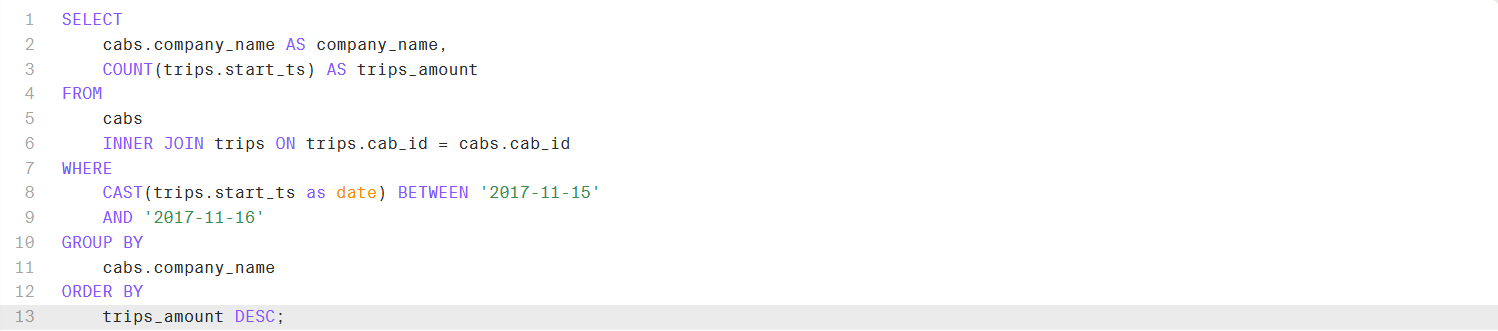

#### Comentarios
* Se solicita que se imprima el campo `company_name`, por lo que en `SELECT`, que es la instrucción fundamental de SQL de consultas, recuperar y visualizar datos almacenados, se debe especificar el campo `company_name`.
* Por otro lado, tenemos la segunda columna `trips_amount` que es la cantidad de viajes en taxi para el 15 y 16 de noviembre de 2017. Para poder hacer el conteo de los viajes por cada compañía de la base de datos, debemos utilizar la cláusula `INNER JOIN`, que sirve para combinar las filas de dos o más tablas que tienen _valores coincidentes_. Debemos detallar cuáles serán los campos coincidentes, que en este caso sería el campo `cab_id` dentro de las tablas `cabs` y `trips`.
* Además, debemos convertir las fechas existentes en el mismo formato, para que se puedan encontrar coincidencias y realizar un análisis efectivo, por lo que en el campo `start_ts` de la tabla `trips` es necesario utilizar la función `CAST` para convertir la fecha en formato `date`, y así utilizarla en conjunto con el operador `BETWEEN` para determinar el rango de fechas a segmentar.
* Por último, utilizar la cláusula `OEDER BY` con el campo `trips_amount` y el complemento `DESC` para que la columna de las compañías de viajes en taxis se encuentre en orden descendente, es decir, de mayor a menor. De esta manera, podemos visualizar primero a las compañías con mayor consumo por parte de los clientes de transporte en taxi.

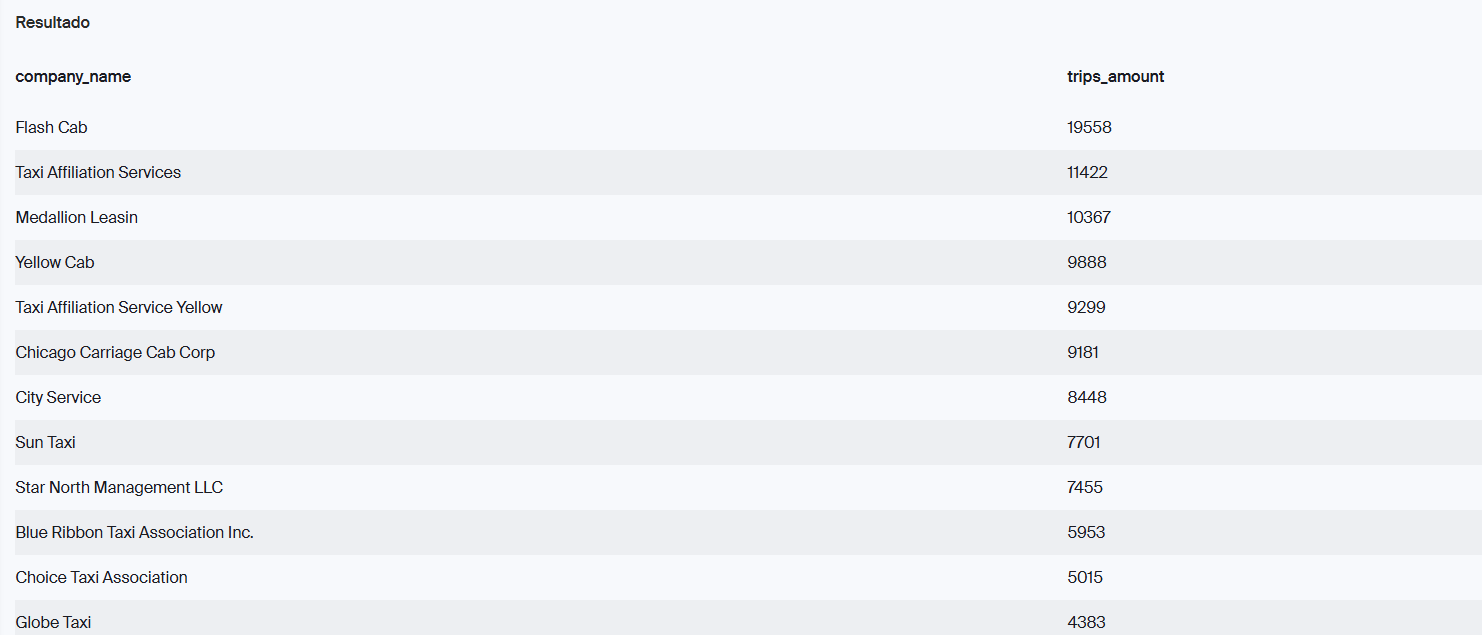

#### Conclusiones
* A partir de los datos resultantes, extraemos la cantidad de viajes realizados por cada compañía de viajes, mostrando un ránking de los más frecuentados en la parte superior entre las fechas 15 y 16 de noviembre del 2017. Esto puede ser vistazo de las compañías con mayor participación de mercado dentro de la indutria de viajes de taxis.

__Se solicita__:
* Encontrar la cantidad de viajes para cada empresa de taxis cuyo nombre contenga las palabras "Yellow" o "Blue" del 1 al 7 de noviembre de 2017.
* Nombrar la variable resultante `trips_amount`.
* Agrupar los resultados por el campo `company_name`.

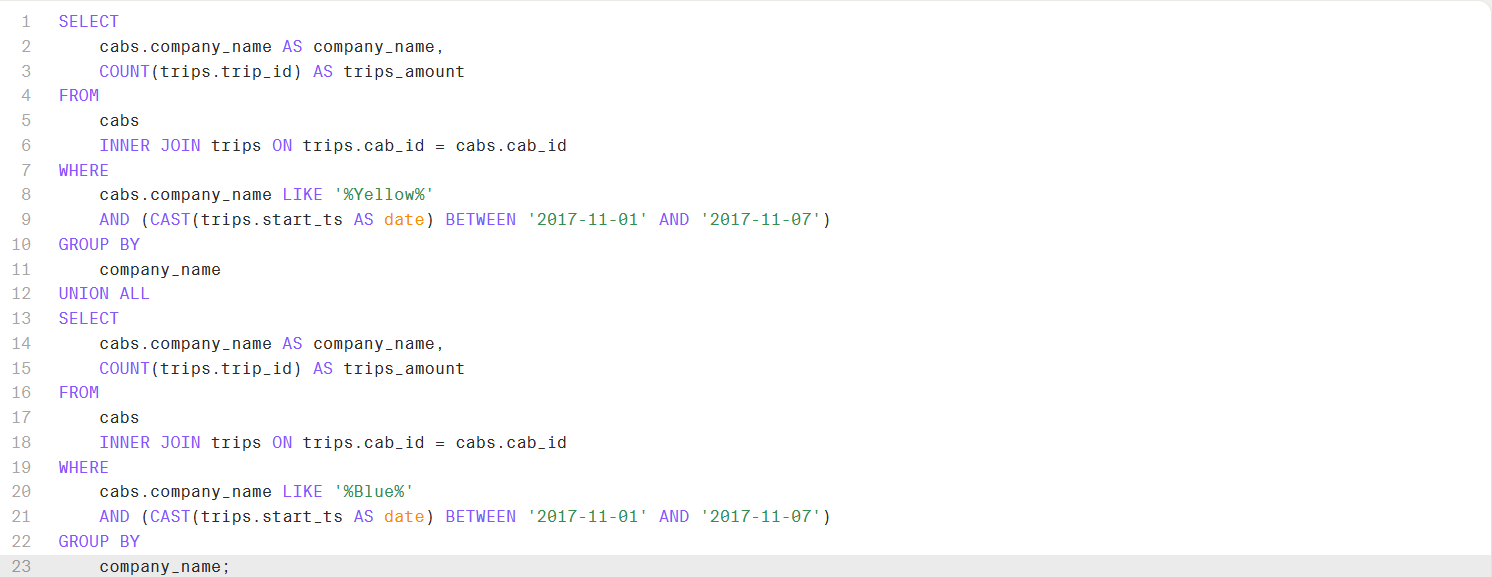

#### Comentarios
* Debemos mantener la base de la consulta anterior, ya que nos están solicitando nuevamente cantidad de viajes dentro de un periodo de tiempo determinado. Sin embargo, hay que ser cuidadoso, debido que los días solicitados son distintos, correspondiente a una semana (1 al 7 de noviembre del 2017).
* Entonces, debemos utilizar la cláusula `WHERE`, que nos permite filtrar y limitar los resultados de una consulta con el uso de condiciones específicas. Por lo tanto, en esta sección se debe determinar la condición en el campo `company_name` y el uso del operador `LIKE` para determinar la condición en cuestión.
* Éstas condiciones son `%Yellow%` y `%Blue%`. ¿Por qué tienen el operador `%`? Este comodín nos indica que existen cadenas de texto posterior a la condición existente, por lo que puede haber un número, letra, carácter o ningún carácter. Es decir, nos indica que cuando está una secuencia de carácteres dentro de %, es que lo que se intenta buscar que contiene la secuencia de carácteres. 
* Además, hacemos uso del operador `UNION ALL` para juntar estas dos consultas, ya que ambas no pueden estar presentes en la misma cláusula `WHERE`, lo que llevaría que la consulta no resulte lo esperado.

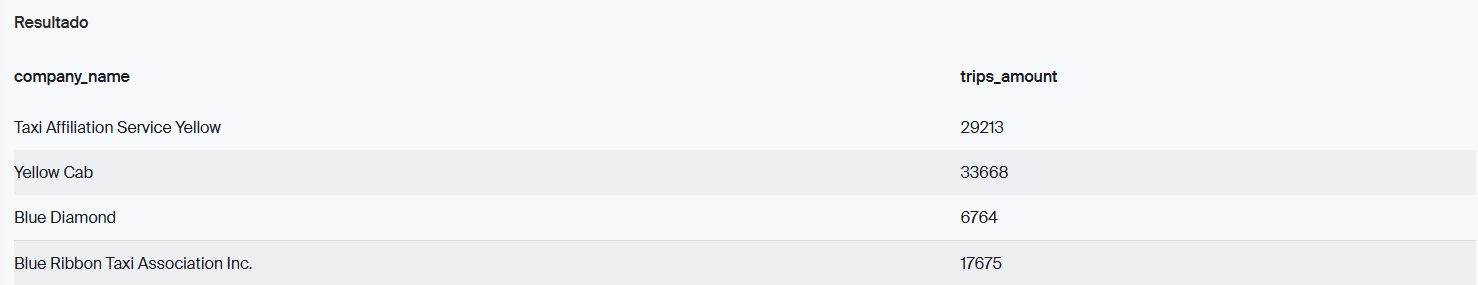

#### Conclusiones
* A través de la consulta se logró identificar la cantidad de viajes realizados por las empresas de taxis cuyos nombres contienen las palabras "Yellow" o "Blue" entre el 1 y el 7 de noviembre de 2017. Para ello se aplicó un filtro por nombre de empresa y se agruparon los resultados por `company_name`, permitiendo calcular el total de viajes de cada compañía en ese periodo.

__Se solicita__:
* Del 1 al 7 de noviembre de 2017, las empresas de taxis más populares fueron `Flash Cab` y `Taxi Affiliation Services`. Encontrar el número de viajes de estas dos empresas y asigna a la variable resultante el nombre `trips_amount`. Juntar los viajes de todas las demás empresas en el grupo `"Other"`.
* Agrupar los datos por nombres de empresas de taxis.
* Asignar el nombre `company` al campo con nombres de empresas de taxis.
* Ordenar el resultado en orden descendente por `trips_amount`.

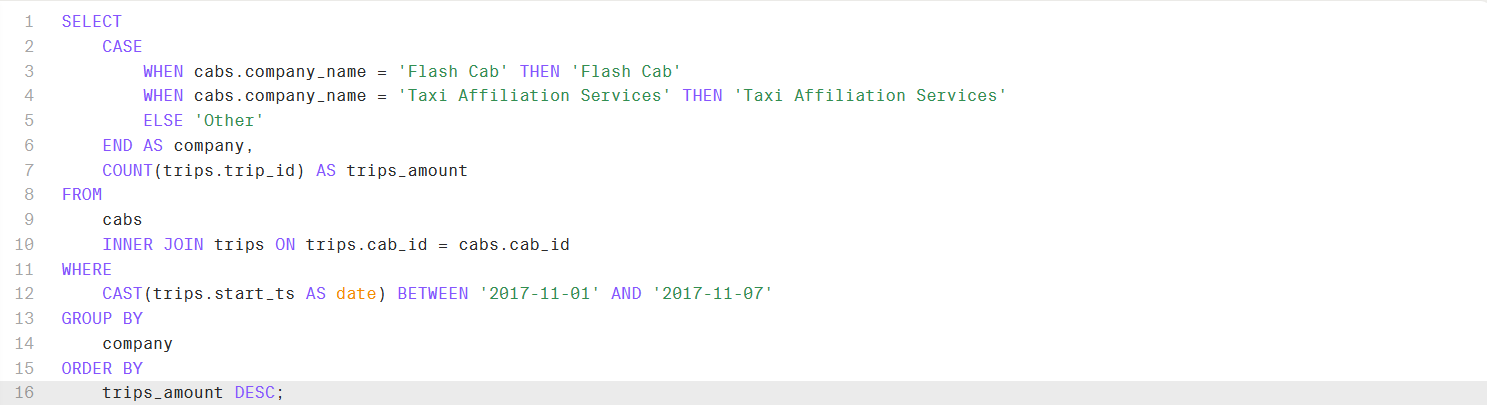

#### Comentarios
* Sabemos muy bien que a partir de los resultados obtenidos anteriormente, las empresas de taxis `Flash Cab` y `Taxi Affiliation Services` son las que están en el top de los usuarios de transporte de taxis. Sin embargo, nos solicitan saber la cantidad de viajes de ambas empresas y el resto de las empresas agruparlas en un ítem llamado `Other`. Por lo tanto, es necesario utilizar dentro de `SELECT` la herramienta de lógica condicional `CASE` para segmentar las compañías de taxis requeridas.
* Además, debemos recalcar que el uso del complemento `END AS company` para dar término a la herramienta de lógica y determinando el nombre de la columna resultante.
*  Por último, el uso de la cláusula `ORDER BY` para dar el orden descendente a partir de la cantidad de viajes por compañía de taxis.

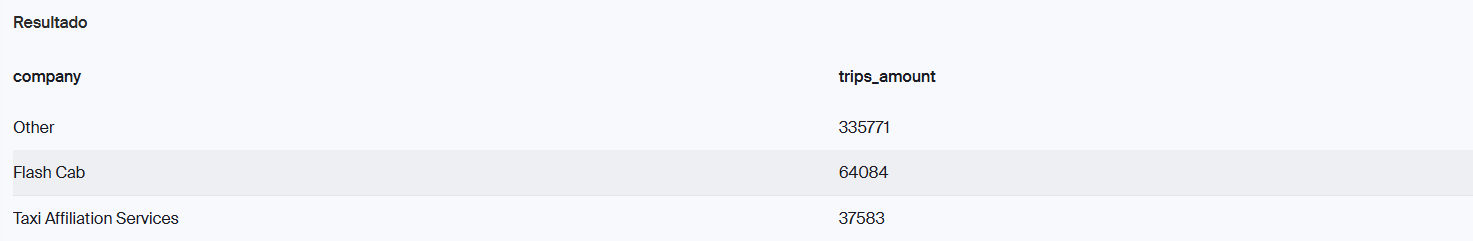

#### Conclusiones
*  En conclusión, podemos determinar que existe una gran participación dentro del mercado de transporte por parte de las compañías `Flash Cab` y `Taxi Affiliation Services`, siendo cercano a un 15% y 9% respectivamente. Sin embargo, podemos identificar que las demás empresas tienen 3/4 del mercado, siendo una oportunidad de introducción de una nueva compañía y/o planificar estrategias de marketing para captar una mayor demanda.

__Se solicita:__
* Recuperar los identificadores de los barrios de `O'Hare` y `Loop` de la tabla `neighborhoods`.

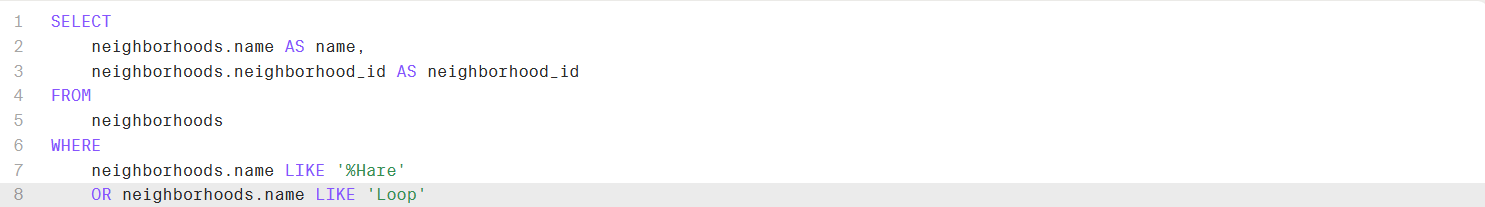

#### Comentarios
* En esta oportunidad, seleccionamos las columnas de `name` y `neighborhood_id` para poder identificar y extraer la información solicitada. Por lo tanto, debemos utilizar nuevamente el operador `LIKE` para condicionar nuestra búsqueda de los identificadores de los barrios `O'Hare` y `Loop`.
* En este caso, no utilizamos los carácteres `%` en su totalidad, solo en el caso de `O'hare` por la simple razón que antes de la `H` hay una `'`, lo que en la búsqueda del identificador se puede ver alterada.

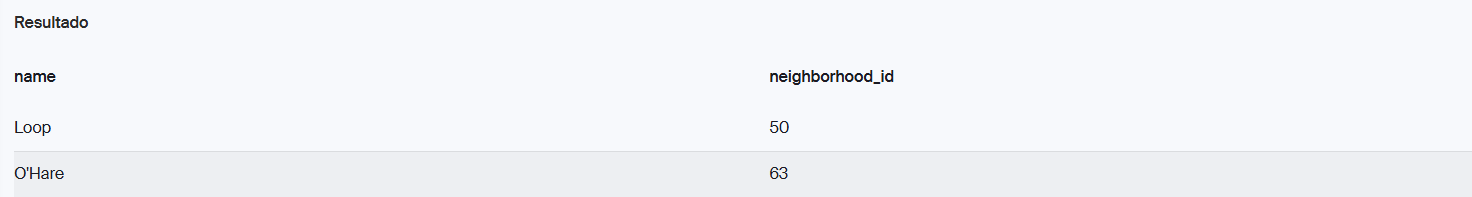

#### Conclusiones
* En esta solicitud, nos permite verificar los identificadores de los barrios requeridos. Además, si es que necesitamos realizar una búsqueda de otros identificadores, tenemos el conocimientos del modus operandis de cómo formmular la consulta de forma sencilla.

__Se solicita:__
* Para cada hora, recuperar los registros de condiciones meteorológicas de la tabla `weather_records`.
* Usando el operador `CASE`, dividir todas las horas en dos grupos: `Bad` si el campo `description` contiene las palabras `rain` o `storm`; y `Good` para los demás.
* Nombrar el campo resultante `weather_conditions`.
* La tabla final debe incluir dos campos: `fecha y hora (ts)` y `weather_conditions`.

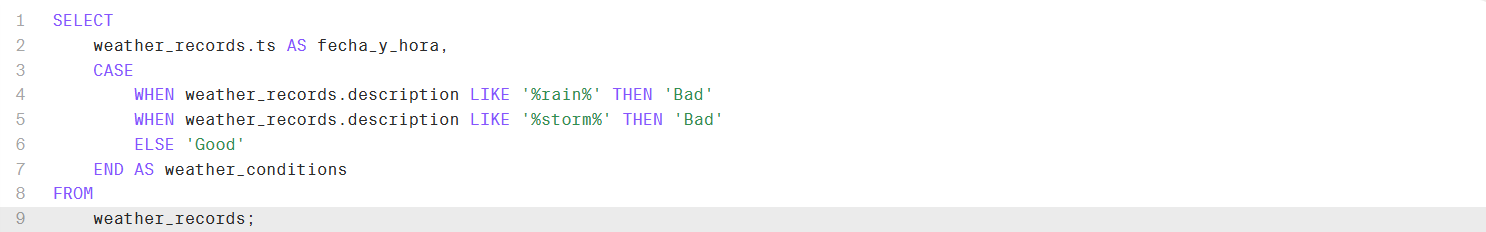

#### Comentarios
* El operador `CASE` es la herramienta necesaria, en conjunto el operador `LIKE`, para poder agrupar en dos distintos grupos a partir del campo `description` para poder determinar si es `Bad`, si es que en la columna `description` contiene las palabras `rain` o `storm`; y `Good` para los demás. Finalmente, en el cierre del operador `CASE` se nombra la columna como `weather_conditions`.
* Cabe destacar que el campo `ts` de la tabla `weather_records` está en el formato necesario para que funcione la consulta.

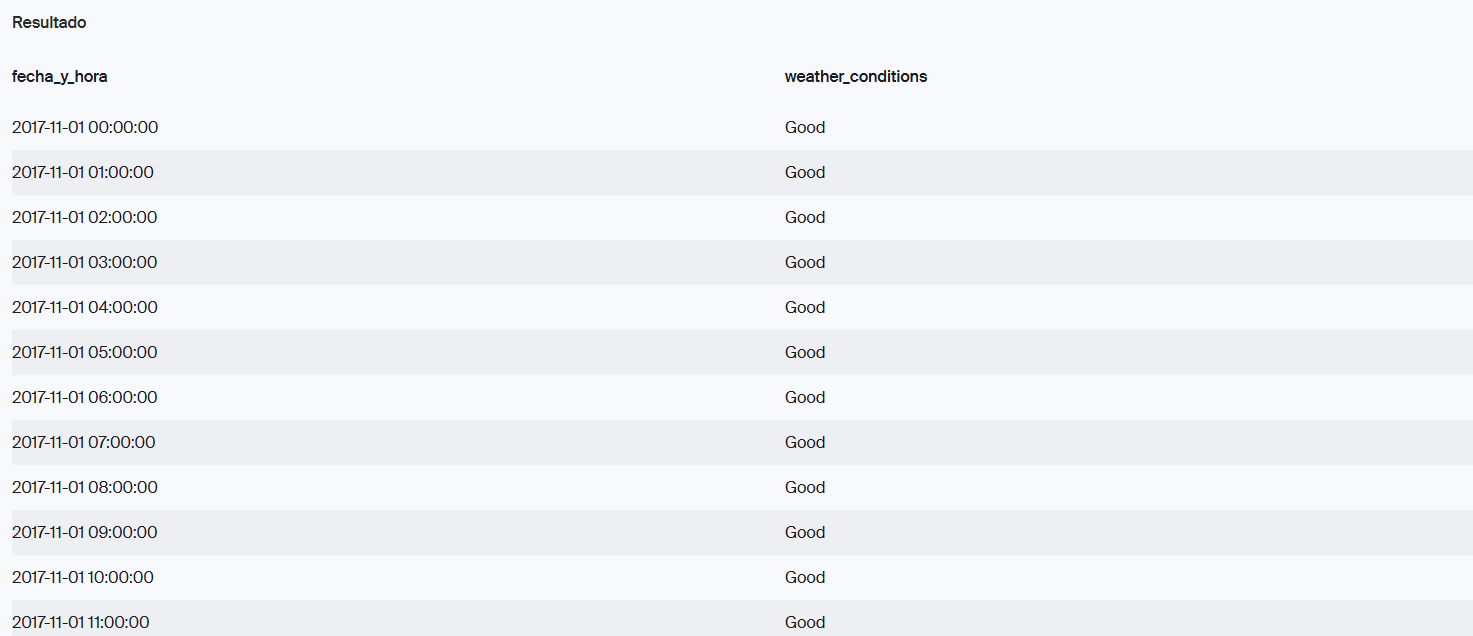

#### Conclusiones
* Por este medio, podemos determinar las condiciones climáticas que existe en la ciudad de Chicago dentro de los días estudiados en la base de datos. Esto nos permite determinar si es que existe una correlación entre las condiciones climáticas y la cantidad de consumo de viajes en taxis.

__Se solicita:__
* Recuperar de la tabla de `trips` todos los viajes que comenzaron en el `Loop` (`pickup_location_id: 50`) el sábado y terminaron en `O'Hare` (`dropoff_location_id: 63`).
* Obtener las condiciones climáticas para cada viaje. Utilizar el método que aplicaste en la tarea anterior.
* Recuperar también la duración de cada viaje. Ignora los viajes para los que no hay datos disponibles sobre las condiciones climáticas.
* Ordena por `trip_id`

Las columnas de la tabla deben estar en el siguiente orden:
* `start_ts`
* `weather_conditions`
* `duration_seconds`

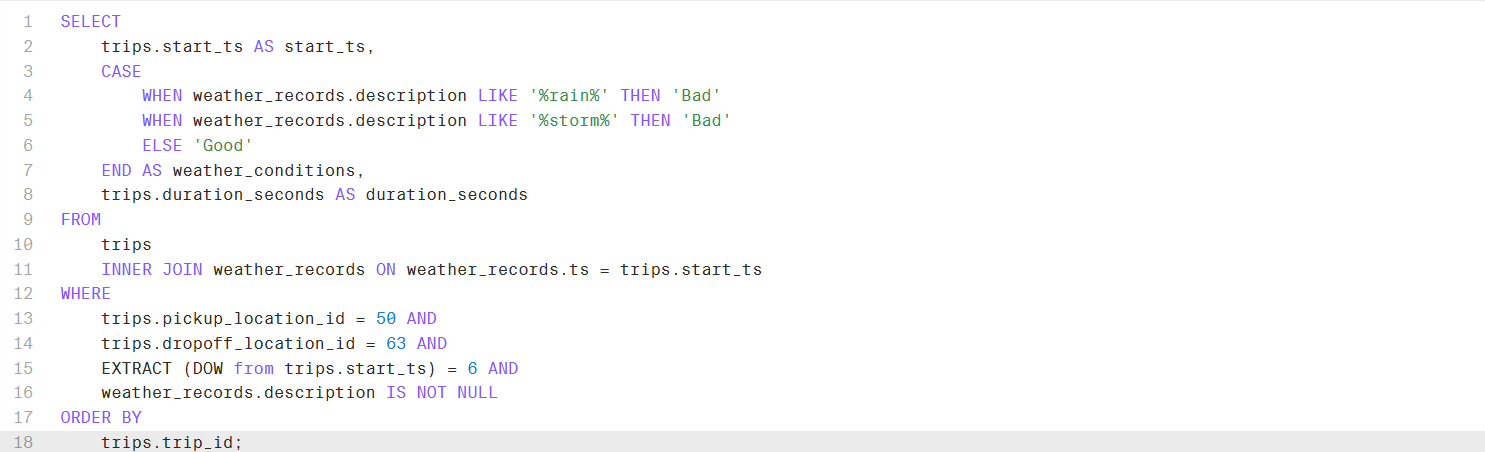

#### Comentarios
* Como base, se puede utilizar la estructura de la consulta anterior para poder responder la solicitud. Adicionando la columna `duration_seconds` de los viajes que fueron registrados con las condiciones climáticas.
* Sin embargo, requerimos la cláusula `INNER JOIN` para combinar las tablas `trips` y `weather_records` a través de los campos `start_ts` y `ts` respectivamente, lo que lleva a que podamos determinar la fecha determinada por el solicitante.
* En la cláusula `WHERE` se realizan todas condicionat es requeridas, por lo que nos limitamos a ir detallando cada una en esta sección. Sin embargo, nos vamos a enfocar en la condición `EXTRACT (DOW from trips.start_ts) = 6`. ¿Por qué 6? Debemos recalcar que cuando uilizamos el complemento `DOW` hace que los días de la semana estén identificados desde el 0 (Domingo) hasta el 6 (Sábado).
* Además, en la condición `weather_records.description IS NOT NULL` nos hace referencia a que debemos solo considerar las filas que contengan información dentro de la columna `description`.

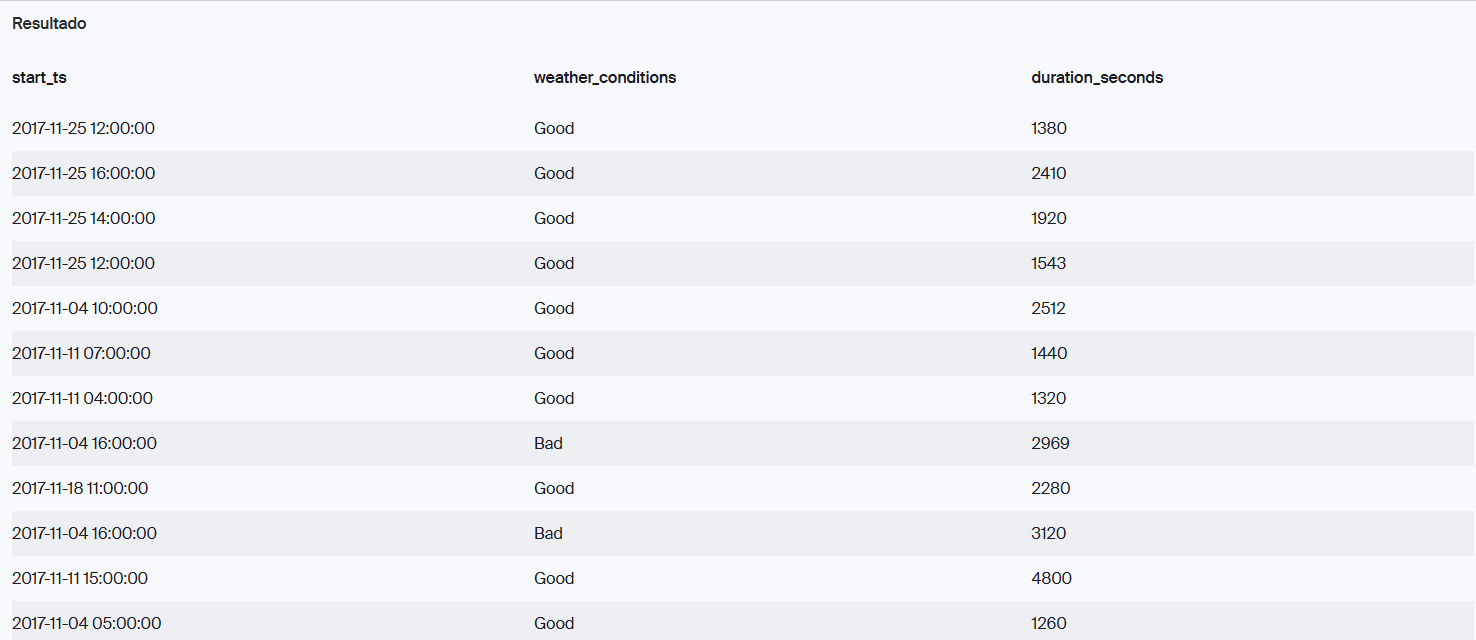

#### Conclusión
* La consulta permitió construir un conjunto de datos específico que relaciona viajes entre el Loop y el Aeropuerto O'Hare con las condiciones climáticas en el momento del inicio del viaje. Al filtrar por día de la semana, origen y destino, y eliminar registros sin información meteorológica, se obtuvo un dataset limpio que permite posteriormente analizar cómo influyen las condiciones climáticas en la duración de los viajes.

## Análisis exploratorio de datos (Python)
Los datos que recuperaste en las tareas anteriores te han dado un segundo archivo. Ahora tienes estos dos CSV:

__/datasets/project_sql_result_01.csv__

Contiene los siguientes datos:
* _company_name_: nombre de la empresa de taxis
* _trips_amount_: el número de viajes de cada compañía de taxis el 15 y 16 de noviembre de 2017. 

__/datasets/project_sql_result_04.csv__

Contiene los siguientes datos:
* _dropoff_location_name_: barrios de Chicago donde finalizaron los viajes
* _average_trips_: el promedio de viajes que terminaron en cada barrio en noviembre de 2017.

Para estos dos datasets ahora necesitas:
* Importar los archivos
* Estudiar los datos que contienen
* Asegurarte de que los tipos de datos sean correctos
* Identificar los 10 principales barrios en términos de finalización del recorrido
* Hacer gráficos: empresas de taxis y número de viajes, los 10 barrios principales por número de finalizaciones
* Sacar conclusiones basadas en cada gráfico y explicar los resultados

In [12]:
# Importar las librerías pandas y matplotlib
import pandas as pd
import matplotlib.pyplot as plt

# Columnas: company_name , trips_amount
cabs = pd.read_csv(r'C:\\Users\\rica/datasets/project_sql_result_01.csv')

# Columnas: dropoff_location_name , average_trips
trips = pd.read_csv(r'C:\\Users\\rica/datasets/project_sql_result_04.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\\\Users\\\\rica/datasets/project_sql_result_01.csv'

In [10]:
import os
os.getcwd()

'C:\\Users\\ricar'